# EMG gesture classification — the baseline classifier in PyTorch and PyTorch Lightning

A port of §1–2 of [`myo-keras.ipynb`](myo-keras.ipynb) — the ordinary supervised baseline — into two
other frameworks, in order:

1. **PyTorch** — the training loop written out by hand, so everything `model.fit` does implicitly
   (batch size, shuffling, running metrics, best-epoch checkpointing, the patience counter) is on
   the page.
2. **PyTorch Lightning** — the same network under the same rules again, with the loop handed back
   to a `Trainer` and the rules expressed as callbacks.

Nothing about the data changes. Features, splits and every hyperparameter still come from
[`myo_utils.py`](myo_utils.py), so all three notebooks train the same architecture on byte-identical
inputs. The grokking experiments (§3–6 of the Keras notebook) are **not** ported — this is the
baseline only. See [`README.md`](README.md) for the write-up of the original.

> **Runtime:** **13 m 29 s** top to bottom for the run stored below, on a 6-core / 12-thread CPU —
> 6.7 s to load the data, **3 m 24 s** for the hand-written PyTorch loop (6 epochs, ~34 s each) and
> **9 m 40 s** for the Lightning one (6 epochs, ~97 s each). Read those as upper bounds, not a rate:
> an earlier execution of this same notebook on this same box — agreeing with the stored one to four
> decimals on every number — finished in **7 m 13 s**, at 21 s and 49 s per epoch. Wall time here
> swings ~2× with CPU governor and background load, which the Keras notebook's README documents at
> length for the grokking runs. The *ratio* is the stable part: Lightning costs ~2.4–2.8× per epoch,
> and that is `DataLoader` overhead rather than compute — see §5. No GPU: 29,538 parameters and
> 32-row batches, so the CPU stack wins here exactly as it does in the Keras notebook.

> **Reproducibility:** deterministic on this machine, and checked rather than assumed.
> `build_model` fixes the weight draw with `torch.manual_seed(SEED)`, the hand-written loop shuffles
> from its own `torch.Generator`, and the Lightning run adds `seed_everything(0, workers=True)` and
> `Trainer(deterministic=True)`. Executed end to end twice (2026-08-04), the two runs agreed on
> **every printed number to four decimals** and wrote **byte-identical** figures. That is one box at
> one thread count, though — thread count changes the order of float reductions, so the last
> decimals can move on different hardware.
>
> What is deliberately *not* shared is the RNG stream *between* frameworks. Keras, the hand-written
> loop and Lightning each shuffle from a different one, so the three rows in §4 are three draws of
> the same procedure rather than one result computed three times. §5 puts a size on the difference
> that makes.

> **Metrics:** the test split is **~56% `hibernation`**, so plain accuracy is scored against a
> **0.564 majority-class floor** — always predicting the resting class already scores that.
> Balanced accuracy (macro recall), whose floor is the 0.125 chance line, is printed next to it
> everywhere. Same rule as the Keras notebook: read both numbers, never just the first.

In [1]:
%pip install -q -r requirements-torch.txt

import logging
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torchinfo import summary
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from myo_utils import *  # constants, RMS features and data loading — shared with the Keras notebook

# Lightning is chatty on a CPU-only box: an accelerator banner, a cloud-logging tip, and a
# num_workers suggestion that does not apply (the datasets are already in memory as tensors, so
# worker processes would only add copies). The pytree DeprecationWarning is raised inside
# Lightning against torch, not by anything here. None of the four are actionable.
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", module=r"lightning\..*")
warnings.filterwarnings("ignore", message=".*LeafSpec.*")

os.makedirs(PICS_DIR, exist_ok=True)  # figures for the README are written here

plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams['figure.figsize'] = FIGURE_SIZE
plt.rcParams['figure.dpi'] = FIGURE_DPI

# Three knobs Keras supplies by default and PyTorch does not, so they get named here:
BATCH_SIZE = 32          # `keras.Model.fit` default; PyTorch has no default at all
EVAL_BATCH_SIZE = 8_192  # no gradients to hold, so evaluation runs in far larger chunks
SEED = 0                 # the seed the Keras baseline cell uses

TORCH_WEIGHTS_FILE = "weights_torch.pt"
LIGHTNING_CKPT_DIR = "checkpoints_lightning"

print(f"Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}  |  "
      f"Lightning {L.__version__}  |  NumPy {np.__version__}")
print(f"device cpu  |  torch threads {torch.get_num_threads()}")

Note: you may need to restart the kernel to use updated packages.


Python 3.12.13  |  PyTorch 2.13.0+cpu  |  Lightning 2.6.5  |  NumPy 2.5.1
device cpu  |  torch threads 6


## 1 — Data

Unchanged from the Keras notebook, and deliberately so: `load_data_curated()` from
[`myo_utils.py`](myo_utils.py) returns the same **causal** sliding-window RMS features (window
`RMS_WINDOW_SIZE` = 80, normalised by 128) over the same curated sessions, split deterministically
by directory suffix — `-1` train, `-2` validation, `-3` test. Same participants, different recording
days, so this is within-subject cross-session.

The only new step is the type conversion. Keras eats NumPy arrays directly; PyTorch wants tensors,
and `nn.NLLLoss` (like `SparseCategoricalCrossentropy`) wants **integer** class indices, so the
labels — which arrive as float64, being the ninth column of a float matrix — are cast to `int64`.

In [2]:
t0 = time.time()
train, train_labels, valid, valid_labels, test, test_labels = load_data_curated()
print(f"train {train.shape}  valid {valid.shape}  test {test.shape}  "
      f"({NUM_GESTURES} gestures, RMS window {RMS_WINDOW_SIZE})  [{time.time() - t0:.1f}s]")


def as_tensors(features, labels):
    """NumPy float64 pair -> (float32 features, int64 class indices)."""
    return (torch.tensor(features, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long))


X_train, y_train = as_tensors(train, train_labels)
X_valid, y_valid = as_tensors(valid, valid_labels)
X_test, y_test = as_tensors(test, test_labels)
print(f"tensors: {tuple(X_train.shape)} {X_train.dtype} / {tuple(y_train.shape)} {y_train.dtype}  "
      f"| {X_train.element_size() * X_train.nelement() / 1e6:.0f} MB train features")

train (480872, 8)  valid (479667, 8)  test (480379, 8)  (8 gestures, RMS window 80)  [6.7s]
tensors: (480872, 8) torch.float32 / (480872,) torch.int64  | 15 MB train features


## 2 — The baseline in PyTorch

### The model, layer for layer

The Keras model this ports:

```python
model = keras.Sequential([
    keras.layers.Input(shape=(NUM_EMG_CHANNELS,)),
    keras.layers.Dense(LAYER_SIZES[0], activation="relu"),
    keras.layers.Dense(LAYER_SIZES[1], activation="relu"),
    keras.layers.Dense(LAYER_SIZES[2], activation="relu"),
    keras.layers.Dense(NUM_GESTURES, activation="softmax"),
])
opt = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(optimizer=opt, loss=loss, metrics=["accuracy"])
```

| Keras | PyTorch |
|---|---|
| `Input(shape=(8,))` | implicit — the first `nn.Linear` declares `in_features=8` |
| `Dense(200, activation="relu")` | `nn.Linear(8, 200)` then `nn.ReLU()` — activation is its own layer |
| `Dense(8, activation="softmax")` | `nn.Linear(70, 8)` then `nn.LogSoftmax(dim=1)` |
| `SparseCategoricalCrossentropy()` | `nn.NLLLoss()` — integer targets, log-probability inputs |
| `Adam(learning_rate=1e-3)` | `torch.optim.Adam(params, lr=1e-3, eps=1e-7)` |
| `metrics=["accuracy"]` | counted by hand in the loop |
| `model.summary()` | `torchinfo.summary(model, input_size=...)` |

Three of those rows hide a real difference rather than a spelling change:

**Softmax + cross-entropy → log-softmax + NLL.** `LogSoftmax` followed by `NLLLoss` is the same
function as softmax followed by sparse categorical cross-entropy, computed in log space where it is
numerically stable. The idiomatic PyTorch spelling is to drop the output activation entirely and use
`nn.CrossEntropyLoss` on raw logits, which is identical again; the explicit `LogSoftmax` layer is
kept here only so the layer list still reads one-for-one against the Keras one. Class
*probabilities*, when wanted, are `model(x).exp()`.

**Initialisation is not the same by default.** `nn.Linear` initialises weights Kaiming-uniform
(`a=√5`) and biases uniform in ±1/√fan_in; Keras `Dense` uses **Glorot-uniform weights and zero
biases**. Left alone that is a genuinely different starting point, not a detail, so `build_model`
overrides both to the Keras defaults.

**Adam's epsilon differs.** Keras defaults to `1e-7`, PyTorch to `1e-8`. `betas` (0.9, 0.999) match.
The gap is small but free to close, so it is closed.

In [3]:
def build_model(seed=SEED):
    """The Keras Sequential above, layer for layer, with Keras's initialisers."""
    torch.manual_seed(seed)  # fixes the initial weight draw
    model = nn.Sequential(
        nn.Linear(NUM_EMG_CHANNELS, LAYER_SIZES[0]), nn.ReLU(),
        nn.Linear(LAYER_SIZES[0], LAYER_SIZES[1]), nn.ReLU(),
        nn.Linear(LAYER_SIZES[1], LAYER_SIZES[2]), nn.ReLU(),
        nn.Linear(LAYER_SIZES[2], NUM_GESTURES), nn.LogSoftmax(dim=1),
    )
    for layer in model:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_uniform_(layer.weight)  # Keras Dense default: glorot_uniform
            nn.init.zeros_(layer.bias)             # Keras Dense default: zeros
    return model


model = build_model()
summary(model, input_size=(1, NUM_EMG_CHANNELS), col_names=("output_size", "num_params"),
        row_settings=("var_names",))

Layer (type (var_name))                  Output Shape              Param #
Sequential (Sequential)                  [1, 8]                    --
├─Linear (0)                             [1, 200]                  1,800
├─ReLU (1)                               [1, 200]                  --
├─Linear (2)                             [1, 100]                  20,100
├─ReLU (3)                               [1, 100]                  --
├─Linear (4)                             [1, 70]                   7,070
├─ReLU (5)                               [1, 70]                   --
├─Linear (6)                             [1, 8]                    568
├─LogSoftmax (7)                         [1, 8]                    --
Total params: 29,538
Trainable params: 29,538
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.12
Estimated Total Size (MB): 0.12

### Training

`model.fit(...)` plus its two callbacks is four separate things, and in PyTorch you write all four:
an epoch loop over shuffled minibatches, running epoch metrics, a best-so-far checkpoint, and a
patience counter. `fit()` below is exactly those four and nothing else.

The checkpoint rule is the one to copy carefully. The Keras notebook flags `save_best_only=True` as
load-bearing: validation loss is lowest at epoch 1 and climbs monotonically after it, so the *last*
epoch is the most overfit model in the run, and restoring it costs ~2–3 points of test accuracy.
Writing the file only inside the `if val_loss < best_val_loss` branch — and reloading it at the end
— is what reproduces that behaviour here. `EarlyStopping(patience=5)` becomes the counter next to
it; note that Keras's early stopping does *not* restore the best weights by default either, which is
precisely why the checkpoint has to.

The train-side loss and accuracy are accumulated across the epoch **as the batches are seen**, with
the weights changing underneath — a running average, not a clean end-of-epoch measurement. That is
the statistic Keras prints, so it is the statistic reproduced here; only the validation numbers
describe a single fixed model.

In [4]:
@torch.no_grad()
def evaluate(model, X, y, batch_size=EVAL_BATCH_SIZE):
    """`model.evaluate` — sample-weighted mean loss and accuracy over one fixed model."""
    model.eval()
    loss_fn = nn.NLLLoss(reduction="sum")
    total_loss, correct = 0.0, 0
    for start in range(0, len(X), batch_size):
        xb, yb = X[start:start + batch_size], y[start:start + batch_size]
        out = model(xb)
        total_loss += loss_fn(out, yb).item()
        correct += (out.argmax(dim=1) == yb).sum().item()
    return total_loss / len(X), correct / len(X)


@torch.no_grad()
def predict_labels(model, X, batch_size=EVAL_BATCH_SIZE):
    """`np.argmax(model.predict(X), axis=1)` — the predicted class per row."""
    model.eval()
    return torch.cat([model(X[s:s + batch_size]).argmax(dim=1)
                      for s in range(0, len(X), batch_size)]).numpy()


def fit(model, X_train, y_train, X_valid, y_valid, *, epochs=EPOCHS, patience=PATIENCE,
        batch_size=BATCH_SIZE, lr=LEARNING_RATE, checkpoint_path=TORCH_WEIGHTS_FILE, seed=SEED):
    """model.fit(..., callbacks=[EarlyStopping, ModelCheckpoint(save_best_only=True)]), written out."""
    loss_fn = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, eps=1e-7)  # eps: Keras default, not torch's
    shuffle_rng = torch.Generator().manual_seed(seed)  # `fit(shuffle=True)` needs its own stream
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
    best_val_loss, epochs_without_improvement = float("inf"), 0
    n = len(X_train)

    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(n, generator=shuffle_rng)
        running_loss, running_correct = 0.0, 0
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]
            optimizer.zero_grad(set_to_none=True)
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()
            # Running epoch means, accumulated as the weights move — the statistic Keras prints.
            running_loss += loss.item() * len(idx)
            running_correct += (out.argmax(dim=1) == yb).sum().item()

        val_loss, val_accuracy = evaluate(model, X_valid, y_valid)
        history["loss"].append(running_loss / n)
        history["accuracy"].append(running_correct / n)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        if val_loss < best_val_loss:            # ModelCheckpoint(save_best_only=True, 'val_loss')
            best_val_loss, epochs_without_improvement = val_loss, 0
            torch.save(model.state_dict(), checkpoint_path)
        else:                                   # EarlyStopping(monitor='val_loss', patience=PATIENCE)
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    return history


def training_summary(history, epochs=EPOCHS):
    """The one line the Keras notebook prints after fitting."""
    best_epoch = int(np.argmin(history["val_loss"])) + 1
    print(f"stopped after {len(history['loss'])}/{epochs} epochs  |  "
          f"best val loss {min(history['val_loss']):.4f} at epoch {best_epoch}  |  "
          f"val accuracy at that epoch {history['val_accuracy'][best_epoch - 1]:.4f}")
    return best_epoch

In [5]:
initial_state = {k: v.clone() for k, v in model.state_dict().items()}  # kept for the §5 check

t0 = time.time()
torch_history = fit(model, X_train, y_train, X_valid, y_valid)
torch_elapsed = time.time() - t0

model.load_state_dict(torch.load(TORCH_WEIGHTS_FILE))  # now genuinely the best-val-loss epoch
torch_best_epoch = training_summary(torch_history)
print(f"trained in {int(torch_elapsed // 60)}m {torch_elapsed % 60:02.0f}s  "
      f"({torch_elapsed / len(torch_history['loss']):.1f}s per epoch)")

stopped after 6/20 epochs  |  best val loss 0.5964 at epoch 1  |  val accuracy at that epoch 0.8372
trained in 3m 24s  (34.1s per epoch)


$\mathcal{L}_{\text{train}}$ vs $\mathcal{L}_{\text{val}}$ and the matching accuracies, per epoch —
the same pair of panels as the Keras notebook. A growing gap between the two loss curves is
overfitting; early stopping cuts training when validation loss stops improving for `PATIENCE` epochs.

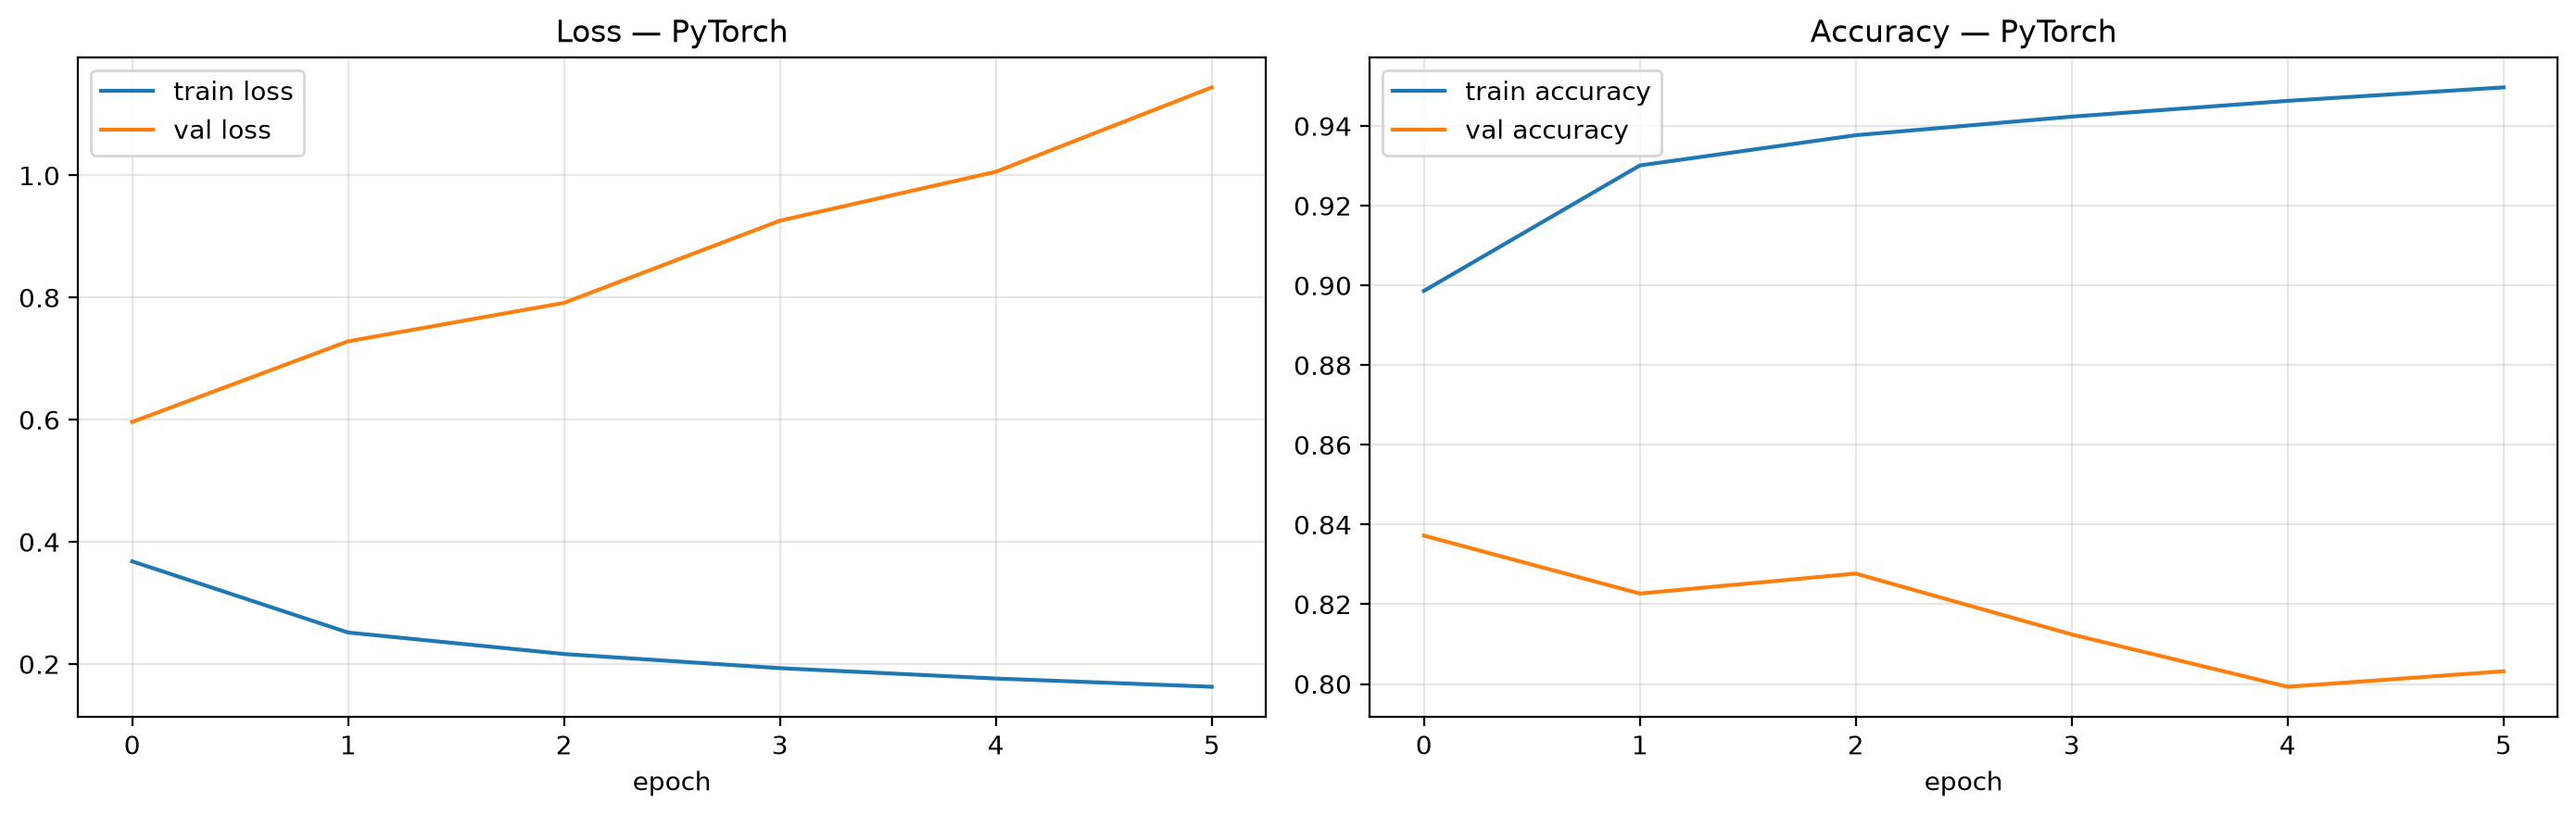

In [6]:
def plot_history(history, title, savepath):
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 4.5))
    ax0.plot(history['loss'], label='train loss')
    ax0.plot(history['val_loss'], label='val loss')
    ax0.set_title(f"Loss — {title}")
    ax1.plot(history['accuracy'], label='train accuracy')
    ax1.plot(history['val_accuracy'], label='val accuracy')
    ax1.set_title(f"Accuracy — {title}")
    for a in (ax0, ax1):
        a.set_xlabel("epoch")
        a.legend()
        a.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    return fig


plot_history(torch_history, "PyTorch", f"{PICS_DIR}/torch_baseline_training.png")
plt.show()

### Evaluation

Held-out test set (`-3` sessions — same participants, a third recording day).

Read two numbers, not one. The split is ~56% `hibernation`, so plain accuracy is scored against a
**majority-class floor of 0.564** — always predicting the resting class already scores that.
**Balanced accuracy** (macro recall) is the metric whose floor is the 0.125 chance line.

In [7]:
def evaluate_and_report(model, name):
    """The two lines the Keras notebook prints, plus the numbers §6 compares."""
    test_loss, test_accuracy = evaluate(model, X_test, y_test)
    predicted = predict_labels(model, X_test)
    majority = np.bincount(test_labels.astype(int)).max() / len(test_labels)
    balanced = balanced_accuracy_score(test_labels, predicted)
    print(f"[{name}] test loss {test_loss:.4f}  |  test accuracy {test_accuracy:.4f}  "
          f"(majority-class floor = {majority:.3f})")
    print(f"[{name}] balanced accuracy (macro recall) {balanced:.4f}  "
          f"(chance = {1 / NUM_GESTURES:.3f})")
    return dict(name=name, test_loss=test_loss, test_accuracy=test_accuracy,
                balanced_accuracy=balanced, predicted=predicted)


torch_result = evaluate_and_report(model, "PyTorch")
predicted_labels = torch_result["predicted"]

[PyTorch] test loss 0.8568  |  test accuracy 0.7841  (majority-class floor = 0.564)
[PyTorch] balanced accuracy (macro recall) 0.6202  (chance = 0.125)


Confusion matrix: rows = ACTUAL, columns = PREDICTED. The diagonal is correct predictions,
off-diagonal are errors. With `normalize="pred"` each **column** sums to 1, so cell $(i, j)$ reads
"of everything predicted $j$, this fraction was really $i$" — i.e. the diagonal is per-class precision.

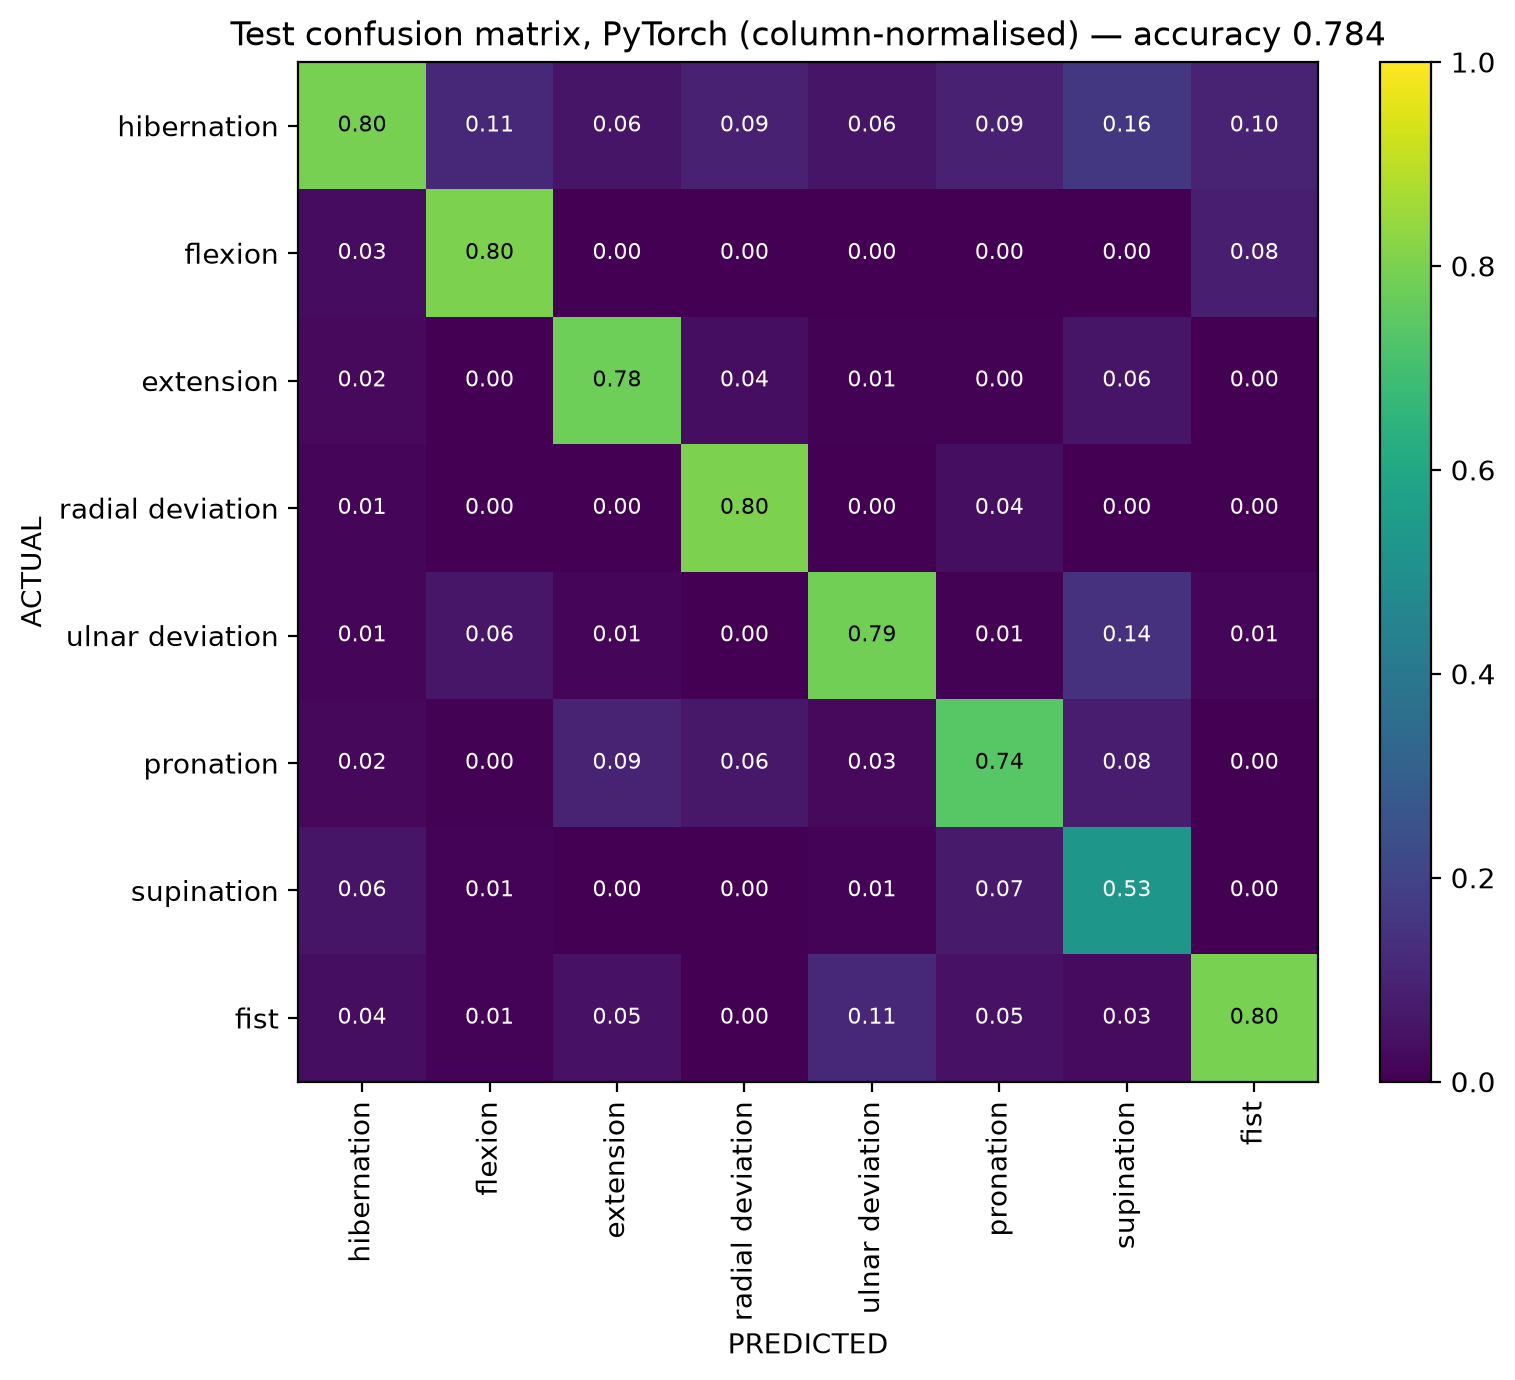

In [8]:
def plot_confusion(predicted, accuracy, title, savepath):
    conf = confusion_matrix(test_labels, predicted, normalize="pred")

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(conf, cmap="viridis", vmin=0, vmax=1)
    for i in range(NUM_GESTURES):
        for j in range(NUM_GESTURES):
            ax.text(j, i, f"{conf[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if conf[i, j] < 0.6 else "black")
    ax.set_ylabel("ACTUAL")
    ax.set_xlabel("PREDICTED")
    ax.set_yticks(np.arange(NUM_GESTURES), GESTURE_LABELS)
    ax.set_xticks(np.arange(NUM_GESTURES), GESTURE_LABELS, rotation='vertical')
    ax.set_title(f"Test confusion matrix, {title} (column-normalised) — accuracy {accuracy:.3f}")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    return conf


plot_confusion(predicted_labels, torch_result["test_accuracy"], "PyTorch",
               f"{PICS_DIR}/torch_baseline_confusion_matrix.png")
plt.show()

Per-class: $\text{Precision}_k = \frac{TP_k}{TP_k+FP_k}$, $\text{Recall}_k = \frac{TP_k}{TP_k+FN_k}$, $\text{F1}_k = 2\frac{P_k R_k}{P_k+R_k}$; support and macro/weighted averages at the bottom.

In [9]:
print(classification_report(test_labels, predicted_labels, target_names=GESTURE_LABELS))

                  precision    recall  f1-score   support

     hibernation       0.80      0.95      0.86    270708
         flexion       0.80      0.60      0.69     29973
       extension       0.78      0.66      0.72     30051
radial deviation       0.80      0.82      0.81     30118
 ulnar deviation       0.79      0.70      0.74     30015
       pronation       0.74      0.55      0.63     30037
      supination       0.53      0.29      0.37     29470
            fist       0.80      0.39      0.53     30007

        accuracy                           0.78    480379
       macro avg       0.75      0.62      0.67    480379
    weighted avg       0.78      0.78      0.77    480379



## 3 — The same run in PyTorch Lightning

Lightning changes nothing about the model, the loss, the optimiser or any hyperparameter. It takes
back the loop, and asks for the *pieces* of the loop as methods instead:

| written by hand above | Lightning |
|---|---|
| `for epoch` / `for batch` | `Trainer.fit(model, train_loader, valid_loader)` |
| `zero_grad()` / `backward()` / `step()` | implied by returning the loss from `training_step` |
| the shuffled index permutation | `DataLoader(..., shuffle=True)` |
| the running-mean bookkeeping | `self.log(..., on_epoch=True)` |
| `if val_loss < best: torch.save(...)` | `ModelCheckpoint(monitor="val_loss", save_top_k=1)` |
| the patience counter | `EarlyStopping(monitor="val_loss", patience=PATIENCE)` |
| `model.load_state_dict(torch.load(...))` | `load_from_checkpoint(checkpoint.best_model_path)` |
| `model.train()` / `model.eval()` / `torch.no_grad()` | handled by the `Trainer` around each loop |

Two details are worth stating rather than trusting:

`self.log(..., on_epoch=True)` reduces by a **batch-size-weighted** mean, but only if it knows the
batch size — it infers one from the batch, and the inference is a guess. Passing `batch_size=len(y)`
explicitly makes the epoch figure a true sample-weighted mean, identical to what `fit()` accumulates
above and to what Keras reports. Without it the ragged last batch of each epoch is over-weighted.

`ModelCheckpoint(save_top_k=1)` is Lightning's `save_best_only=True`, and it is load-bearing for the
same reason as before: `Trainer.fit` leaves the *last* epoch's weights in the module, which on this
task is the most overfit model in the run. The reload after `fit` is not optional.

In [10]:
class LitBaseline(L.LightningModule):
    """The §2 network and the §2 training rules, as a LightningModule."""

    def __init__(self, lr=LEARNING_RATE, seed=SEED):
        super().__init__()
        self.save_hyperparameters()
        self.net = build_model(seed)  # same seed, same initialiser -> same starting weights
        self.loss_fn = nn.NLLLoss()

    def forward(self, x):
        return self.net(x)

    def _shared_step(self, batch, prefix):
        x, y = batch
        out = self(x)
        loss = self.loss_fn(out, y)
        accuracy = (out.argmax(dim=1) == y).float().mean()
        # batch_size makes the epoch reduction sample-weighted rather than batch-weighted.
        self.log_dict({f"{prefix}loss": loss, f"{prefix}accuracy": accuracy},
                      on_step=False, on_epoch=True, batch_size=len(y))
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "")

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, "val_")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr, eps=1e-7)


class HistoryCallback(L.Callback):
    """Collects the four series `keras.callbacks.History` does, so §2's plotting code is reused.

    Read at `on_train_epoch_end`, which fires after the epoch's validation loop — by then all four
    epoch metrics are in `callback_metrics`.
    """

    def __init__(self):
        self.history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    def on_train_epoch_end(self, trainer, pl_module):
        for key in self.history:
            self.history[key].append(float(trainer.callback_metrics[key]))

In [11]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(TensorDataset(X_valid, y_valid), batch_size=EVAL_BATCH_SIZE, shuffle=False)

L.seed_everything(SEED, workers=True, verbose=False)
lit_model = LitBaseline()

# Same seed and same initialiser as §2, so the two runs start from the identical tensors —
# asserted rather than assumed, since it is the only thing making §6's comparison meaningful.
assert all(torch.equal(initial_state[k], v) for k, v in lit_model.net.state_dict().items())
print("initial weights identical to the PyTorch run: True")

checkpoint = ModelCheckpoint(dirpath=LIGHTNING_CKPT_DIR, filename="baseline-best",
                             monitor="val_loss", mode="min", save_top_k=1)  # == save_best_only
early_stopping = EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE)
history_callback = HistoryCallback()

trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="cpu",
    devices=1,
    callbacks=[early_stopping, checkpoint, history_callback],
    logger=False,               # no TensorBoard/CSV writer — the history callback is the record
    enable_progress_bar=False,  # the notebook stays quiet, like the Keras one
    enable_model_summary=False,
    num_sanity_val_steps=0,
    deterministic=True,
)

t0 = time.time()
trainer.fit(lit_model, train_loader, valid_loader)
lightning_elapsed = time.time() - t0

# fit() leaves the LAST epoch in memory; this is the best-val-loss one.
lit_model = LitBaseline.load_from_checkpoint(checkpoint.best_model_path)
lightning_history = history_callback.history
lightning_best_epoch = training_summary(lightning_history)
print(f"trained in {int(lightning_elapsed // 60)}m {lightning_elapsed % 60:02.0f}s  "
      f"({lightning_elapsed / len(lightning_history['loss']):.1f}s per epoch)")

initial weights identical to the PyTorch run: True


stopped after 6/20 epochs  |  best val loss 0.6598 at epoch 1  |  val accuracy at that epoch 0.8245
trained in 9m 40s  (96.6s per epoch)


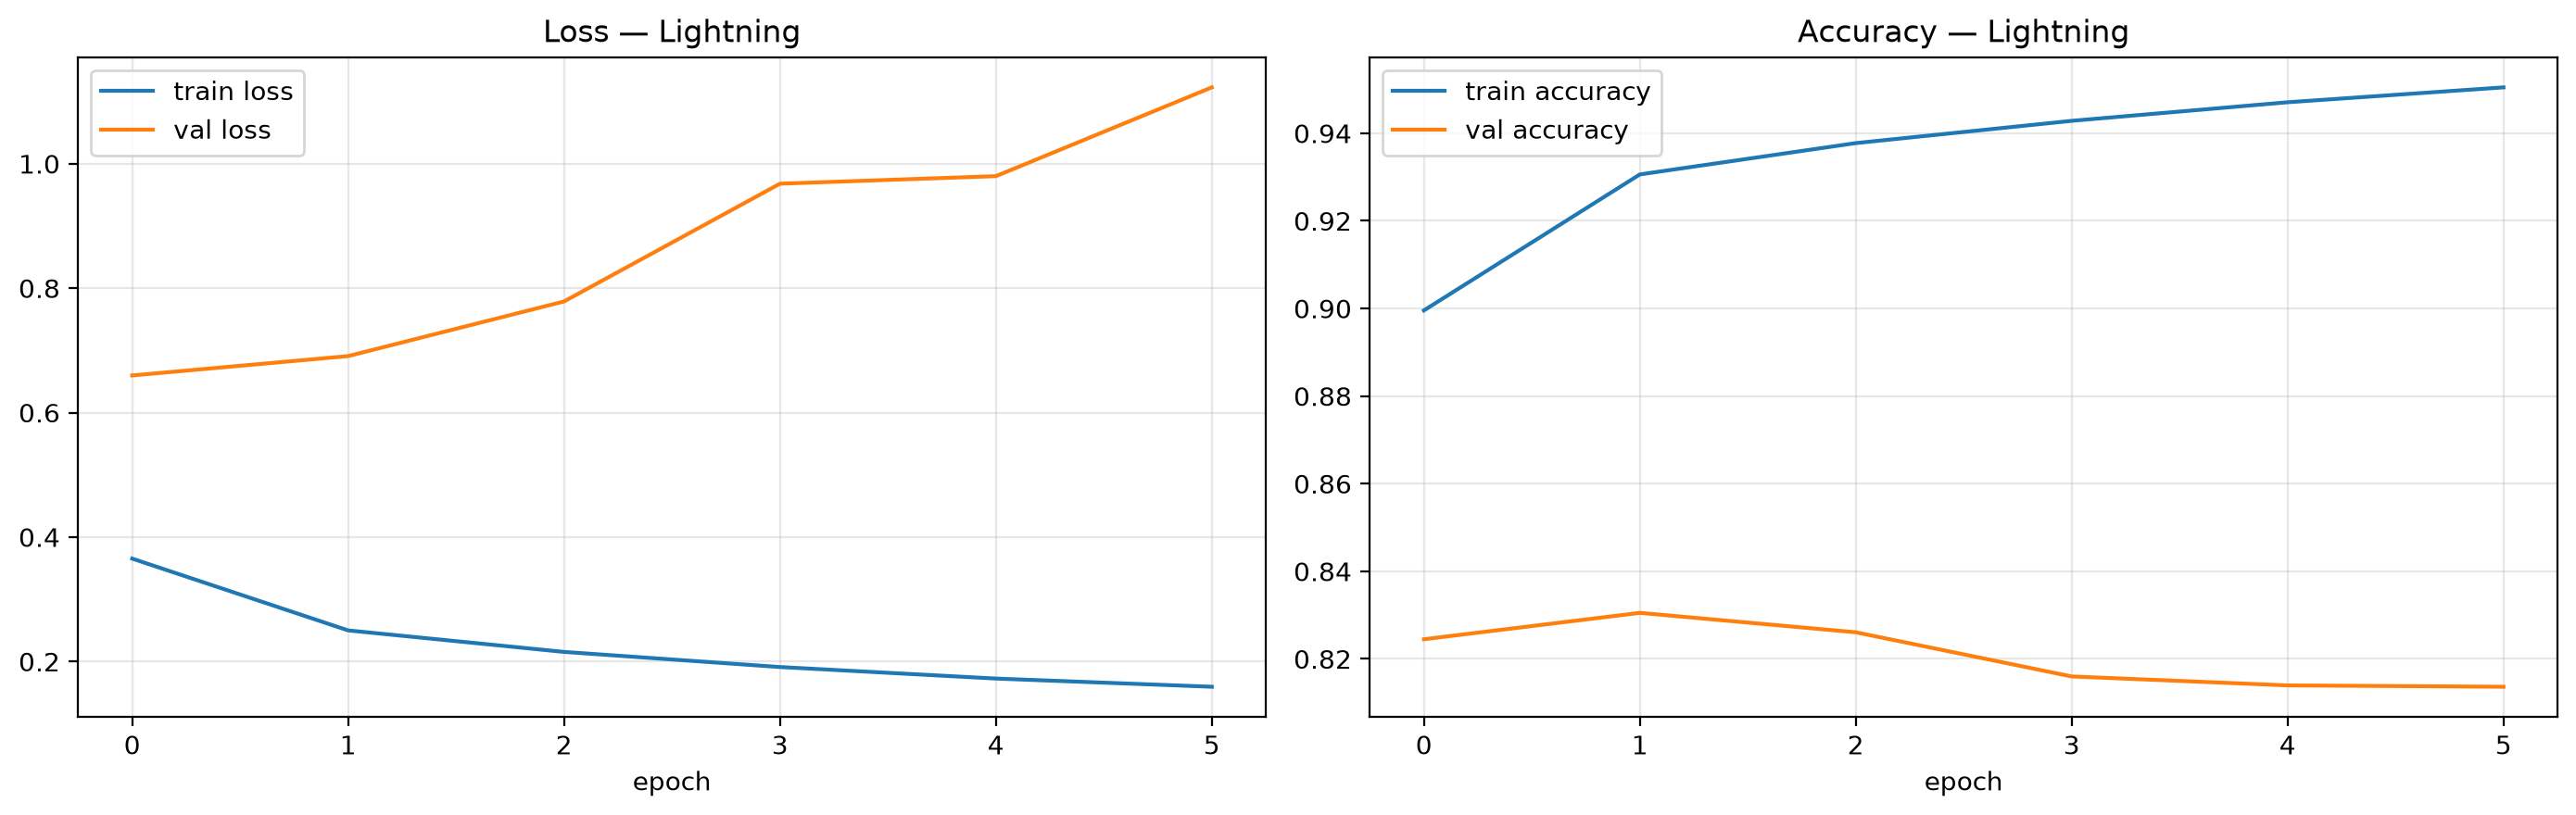

In [12]:
plot_history(lightning_history, "Lightning", f"{PICS_DIR}/lightning_baseline_training.png")
plt.show()

In [13]:
lightning_result = evaluate_and_report(lit_model, "Lightning")
lightning_predicted = lightning_result["predicted"]

[Lightning] test loss 0.9393  |  test accuracy 0.7668  (majority-class floor = 0.564)
[Lightning] balanced accuracy (macro recall) 0.5807  (chance = 0.125)


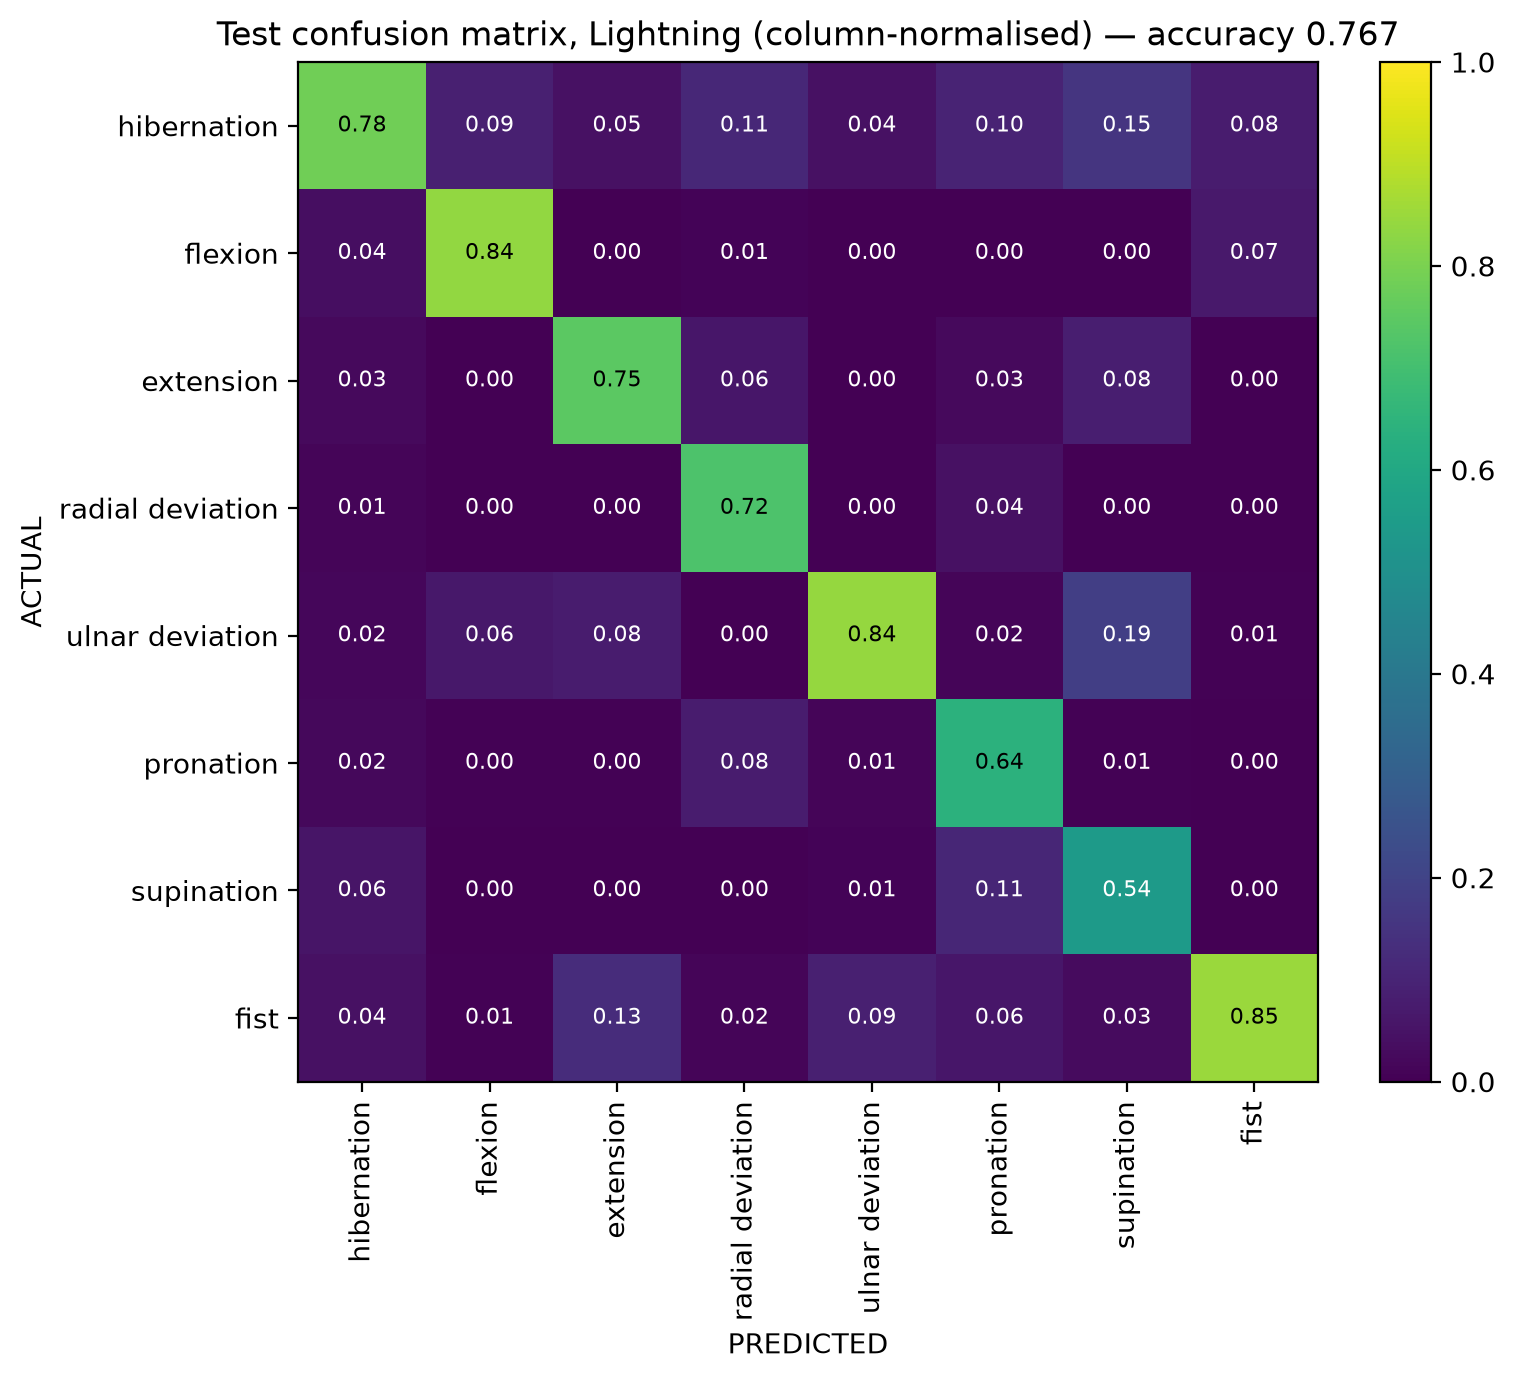

In [14]:
plot_confusion(lightning_predicted, lightning_result["test_accuracy"], "Lightning",
               f"{PICS_DIR}/lightning_baseline_confusion_matrix.png")
plt.show()

In [15]:
print(classification_report(test_labels, lightning_predicted, target_names=GESTURE_LABELS))

                  precision    recall  f1-score   support

     hibernation       0.78      0.95      0.86    270708
         flexion       0.84      0.54      0.66     29973
       extension       0.75      0.58      0.66     30051
radial deviation       0.72      0.82      0.77     30118
 ulnar deviation       0.84      0.60      0.70     30015
       pronation       0.64      0.66      0.65     30037
      supination       0.54      0.22      0.32     29470
            fist       0.85      0.26      0.40     30007

        accuracy                           0.77    480379
       macro avg       0.75      0.58      0.63    480379
    weighted avg       0.76      0.77      0.74    480379



## 4 — The three implementations, side by side

Same architecture, same initialiser, same optimiser and epsilon, same batch size, same early-stopping
and checkpointing rules, same data. The Keras row is **quoted** from the committed run of
[`myo-keras.ipynb`](myo-keras.ipynb) — it is not re-run here — and the two PyTorch rows are measured
in this notebook.

They do not agree exactly, and they cannot. The three frameworks draw their shuffling order from
different RNG streams, so each epoch sees the batches in a different order; the initial weights are
identical between the two PyTorch runs (asserted above) but not shared with Keras at all, since
Keras seeds its own Glorot draw. The scale to read the differences against is the Keras notebook's
own measurement of unseeded reruns: **~0.72–0.78 test accuracy**. Anything inside that band is a
different draw, not a different method.

In [16]:
from IPython.display import Markdown

# Quoted from the committed run of myo-keras.ipynb (see README, "The baseline classifier").
KERAS_RUN = dict(name="Keras (quoted)", epochs=6, best_epoch=1, best_val_loss=0.6614,
                 val_accuracy=0.8164, test_loss=0.8542, test_accuracy=0.7708,
                 balanced_accuracy=0.5854, elapsed="~3m")


def row(name, history, result, elapsed):
    best = int(np.argmin(history["val_loss"]))
    return dict(name=name, epochs=len(history["loss"]), best_epoch=best + 1,
                best_val_loss=min(history["val_loss"]), val_accuracy=history["val_accuracy"][best],
                test_loss=result["test_loss"], test_accuracy=result["test_accuracy"],
                balanced_accuracy=result["balanced_accuracy"],
                elapsed=f"{int(elapsed // 60)}m {elapsed % 60:02.0f}s")


rows = [KERAS_RUN,
        row("PyTorch", torch_history, torch_result, torch_elapsed),
        row("Lightning", lightning_history, lightning_result, lightning_elapsed)]

table = ["| | epochs run | best epoch | best val loss | val accuracy | test loss | "
         "test accuracy | balanced accuracy | train time |", "|---|---|---|---|---|---|---|---|---|"]
for r in rows:
    table.append("| **{name}** | {epochs}/{EPOCHS} | {best_epoch} | {best_val_loss:.4f} | "
                 "{val_accuracy:.4f} | {test_loss:.4f} | {test_accuracy:.4f} | "
                 "{balanced_accuracy:.4f} | {elapsed} |".format(EPOCHS=EPOCHS, **r))
table.append("| chance / floor | | | | | | 0.564 (majority) | 0.125 | |")
display(Markdown("\n".join(table)))

# Both metrics, because the spread is not the same size in each — and balanced accuracy is the
# one the grokking half of the project compares against.
for key, label in (("test_accuracy", "test accuracy    "), ("balanced_accuracy", "balanced accuracy")):
    values = [r[key] for r in rows]
    print(f"{label} across the three implementations: {min(values):.4f} - {max(values):.4f}  "
          f"(spread {max(values) - min(values):.4f})")
print("for scale: unseeded reruns of the Keras baseline span ~0.72-0.78 test accuracy, a ~0.06 band")
print("max |PyTorch - Lightning| per epoch: " + "  ".join(
    f"{k} {max(abs(a - b) for a, b in zip(torch_history[k], lightning_history[k])):.4f}"
    for k in torch_history))

| | epochs run | best epoch | best val loss | val accuracy | test loss | test accuracy | balanced accuracy | train time |
|---|---|---|---|---|---|---|---|---|
| **Keras (quoted)** | 6/20 | 1 | 0.6614 | 0.8164 | 0.8542 | 0.7708 | 0.5854 | ~3m |
| **PyTorch** | 6/20 | 1 | 0.5964 | 0.8372 | 0.8568 | 0.7841 | 0.6202 | 3m 24s |
| **Lightning** | 6/20 | 1 | 0.6598 | 0.8245 | 0.9393 | 0.7668 | 0.5807 | 9m 40s |
| chance / floor | | | | | | 0.564 (majority) | 0.125 | |

test accuracy     across the three implementations: 0.7668 - 0.7841  (spread 0.0173)
balanced accuracy across the three implementations: 0.5807 - 0.6202  (spread 0.0394)
for scale: unseeded reruns of the Keras baseline span ~0.72-0.78 test accuracy, a ~0.06 band
max |PyTorch - Lightning| per epoch: loss 0.0037  accuracy 0.0009  val_loss 0.0634  val_accuracy 0.0147


## 5 — What this port does and does not show

**Does:** the baseline transfers cleanly. All three implementations stop in the same place — 6 of a
possible 20 epochs, best validation loss at epoch 1 — and land within **0.017** of each other on
plain test accuracy (0.767–0.784, against the 0.564 majority-class floor). The per-class picture is
the same in all three too: recall 0.95 on `hibernation`, 0.22–0.82 across the seven active gestures,
and `supination` worst every time. That shape is a property of the features and the split, not of
the framework.

**Does not:** this is neither a bit-exact reproduction nor a benchmark. Each row is n=1 from a
different RNG stream, so a point or two of test accuracy between them is one draw against another
and nothing more. The scale to read them against is the Keras notebook's own unseeded-rerun band,
~0.72–0.78 — about three times the spread measured here.

Balanced accuracy spreads further than plain accuracy across the three rows: **0.581–0.620**, a
0.040 gap against 0.017. That is the metric doing its job rather than extra noise. Plain accuracy is
anchored by `hibernation`, 56% of the split and at 0.95 recall in every run; balanced accuracy
weights all eight classes equally, so it is carried by exactly the minority-class recalls that move
most between draws — `fist` alone ranges 0.26–0.41 across the three. Ranking frameworks on that
number would take repeated runs of each, which is not what this notebook is for.

Lightning costs more per epoch than the hand-written loop — 97 s against 34 s in the run stored
here, 49 s against 21 s in an earlier one, so ~2.4–2.8× either way — for a mundane reason: `DataLoader` re-collates 32-row batches out of tensors that were already resident in memory,
which the hand-written loop skips by slicing them directly. What Lightning buys is not speed. It is
that `EarlyStopping`, `ModelCheckpoint` and the train/eval-mode switching stop being code you can
get subtly wrong — the `save_best_only` trap the Keras notebook documents is one callback argument
in either framework, but the hand-written loop has to re-earn it in an `if` statement every time.